# Activation Functions and Optimization Algorithms

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Plot and compare common activation functions (ReLU, sigmoid, tanh)
- Understand why we use ReLU in hidden layers instead of sigmoid
- See how optimizers (SGD vs Adam) affect training on a tiny example

---

## 🌍 Real life

**Where is this used?** Activation functions appear in **every layer** of neural networks (speech, vision, NLP). Optimizers (SGD, Adam) are used in **all deep learning training** in industry and research.

**In this notebook we use** **activation functions** to introduce **non-linearity** so the network can learn complex patterns. We use **ReLU** in hidden layers (instead of sigmoid) **because** ReLU avoids vanishing gradients and trains faster. We compare **SGD and Adam** so you see how the choice of optimizer affects convergence.

**📌 Covers slide(s):** **19** — Perceptron, MLP, activation functions (revisit). *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Activation function:** Applied after each layer (except sometimes the output). Without it, stacking layers would be equivalent to one linear layer.
- **ReLU:** max(0, x). Fast, avoids vanishing gradient in positive part; used in most hidden layers.
- **Sigmoid / tanh:** Saturate for large |x|, so gradients can vanish; used in outputs (e.g. sigmoid for binary) or in gates (LSTM).
- **Optimizer:** Updates weights using gradients. **SGD:** one learning rate for all. **Adam:** per-parameter adaptive rates; usually converges faster in practice.
- **We use ReLU in hidden layers** instead of sigmoid because ReLU trains faster and avoids vanishing gradients.

### Key math (required)

- **ReLU:** \(\text{ReLU}(x) = \max(0, x)\); derivative: \(1\) if \(x>0\), \(0\) if \(x\le 0\).
- **Sigmoid:** \(\sigma(x) = \frac{1}{1+e^{-x}}\); derivative \(\sigma'(x) = \sigma(x)(1-\sigma(x))\).
- **Tanh:** \(\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}\); derivative \(1 - \tanh^2(x)\).
- **SGD update:** \(w \leftarrow w - \eta\,\nabla_w L\). **Adam** uses adaptive estimates of first and second moments of gradients; see slides or reference for the full formula.

**The steps below put this theory into code.**

💡 **If this is unclear:** First run the **activation plots** (ReLU, sigmoid, tanh) — they show why we use ReLU in hidden layers. Then run the **optimizer comparison** (SGD vs Adam). One sentence: ReLU avoids vanishing gradients; Adam adapts the learning rate per parameter. If stuck, tell your instructor: "I didn't get the activation or optimizer part in notebook 04."


## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow (optional). We use a small grid of values to plot activations and a tiny MNIST subset to compare optimizers.

**Dataset:** Real — MNIST (small subset for SGD vs Adam comparison).

**Outputs:** One figure with activation curves (ReLU, sigmoid, tanh) with axis labels; one short comparison of SGD vs Adam loss after a few steps (printed or small plot).

## Step 1: Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

print("NumPy, Matplotlib ready.", "TensorFlow:", "yes" if HAS_TF else "no")

NumPy, Matplotlib ready. TensorFlow: yes


## Step 2: Define and plot activation functions (we use ReLU in hidden layers instead of sigmoid to avoid vanishing gradients)

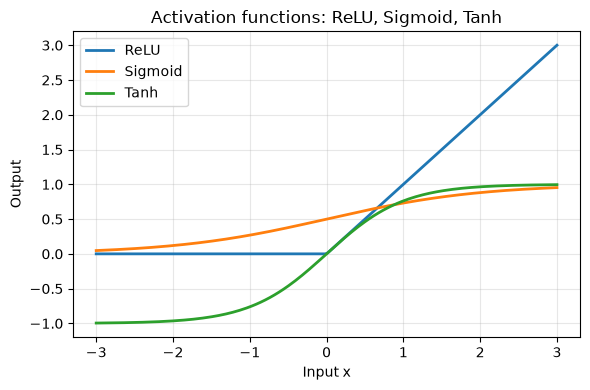

ReLU: no saturation for x>0; sigmoid/tanh saturate and can cause vanishing gradients.


In [2]:
x = np.linspace(-3, 3, 200)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, relu, label="ReLU", linewidth=2)
ax.plot(x, sigmoid, label="Sigmoid", linewidth=2)
ax.plot(x, tanh, label="Tanh", linewidth=2)
ax.set_xlabel("Input x")
ax.set_ylabel("Output")
ax.set_title("Activation functions: ReLU, Sigmoid, Tanh")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("ReLU: no saturation for x>0; sigmoid/tanh saturate and can cause vanishing gradients.")

## Step 3: Compare SGD vs Adam on a tiny MNIST subset (we use Adam when we want faster convergence)

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


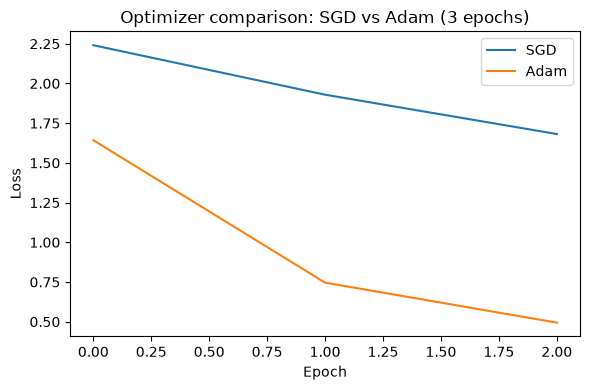

Final loss SGD: 1.6816  Adam: 0.4944


In [3]:
if not HAS_TF:
    print("Skipping optimizer comparison (TensorFlow not available). Install: pip install tensorflow")
else:
    (x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
    x_train = x_train.astype(np.float32) / 255.0
    x_train = x_train.reshape(-1, 784)[:2000]
    y_train = y_train[:2000]

    def build_model():
        return tf.keras.Sequential([
            tf.keras.layers.Dense(64, activation="relu", input_shape=(784,)),
            tf.keras.layers.Dense(10, activation="softmax"),
        ])

    # SGD
    model_sgd = build_model()
    model_sgd.compile(optimizer="sgd", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist_sgd = model_sgd.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0)

    # Adam
    model_adam = build_model()
    model_adam.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    hist_adam = model_adam.fit(x_train, y_train, epochs=3, batch_size=64, verbose=0)

    plt.figure(figsize=(6, 4))
    plt.plot(hist_sgd.history["loss"], label="SGD")
    plt.plot(hist_adam.history["loss"], label="Adam")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Optimizer comparison: SGD vs Adam (3 epochs)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print("Final loss SGD: %.4f  Adam: %.4f" % (hist_sgd.history["loss"][-1], hist_adam.history["loss"][-1]))

## 🌍 Real-World Worked Example — Comparing Optimizers on Image Classification

**Industry context:** Choosing the right optimizer directly impacts training speed and final accuracy.  
OpenAI uses AdamW for GPT models; Google used Adafactor for T5.

We compare SGD, RMSprop, and Adam on the **Digits** dataset to see the difference.

SGD (lr=0.01)        → final acc: 79.4%
RMSprop              → final acc: 97.8%
Adam                 → final acc: 96.9%


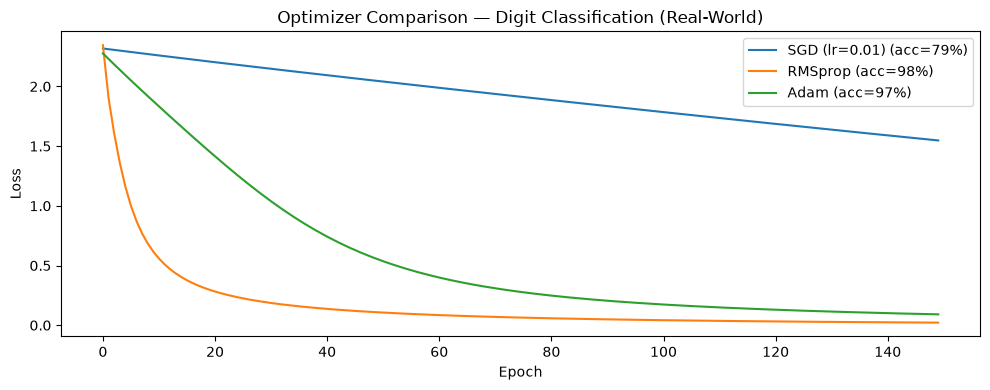

In [4]:
import torch, torch.nn as nn
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

digits = load_digits()
X = StandardScaler().fit_transform(digits.data.astype(np.float32))
y = digits.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
Xtr = torch.tensor(X_tr); Ytr = torch.tensor(y_tr, dtype=torch.long)
Xte = torch.tensor(X_te); Yte = torch.tensor(y_te, dtype=torch.long)

def make_model():
    return nn.Sequential(nn.Linear(64,128), nn.ReLU(), nn.Linear(128,10))

optimizers = {
    'SGD (lr=0.01)':   lambda m: torch.optim.SGD(m.parameters(), lr=0.01),
    'RMSprop':         lambda m: torch.optim.RMSprop(m.parameters(), lr=1e-3),
    'Adam':            lambda m: torch.optim.Adam(m.parameters(), lr=1e-3),
}
results = {}
for name, opt_fn in optimizers.items():
    model = make_model()
    opt   = opt_fn(model)
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for _ in range(150):
        model.train()
        loss = loss_fn(model(Xtr), Ytr)
        opt.zero_grad(); loss.backward(); opt.step()
        curve.append(loss.item())
    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1)==Yte).float().mean().item()
    results[name] = (curve, acc)
    print(f"{name:20s} → final acc: {acc*100:.1f}%")

plt.figure(figsize=(10,4))
for name,(curve,acc) in results.items():
    plt.plot(curve, label=f"{name} (acc={acc*100:.0f}%)")
plt.title("Optimizer Comparison — Digit Classification (Real-World)"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it (choose one):** Change the learning rate for Adam (e.g. from 0.001 to 0.01 or 0.0001) and run the training cell again. How does the loss curve change? Or try plotting one more activation (e.g. Leaky ReLU) in the first cell.

---

## ✅ Summary

**What you did:**
- Plotted ReLU, sigmoid, and tanh and saw why ReLU is preferred in hidden layers.
- Compared SGD and Adam on a tiny MNIST subset; Adam usually decreases loss faster.

**In real life you'd also:** Tune learning rate for SGD, try other activations (e.g. GELU), and use learning rate schedules.

**The main idea:** Activations add non-linearity; ReLU is the default for hidden layers. Optimizers (SGD, Adam) control how weights are updated; Adam often converges faster.

**Next:** `06_optimization_techniques` goes deeper into optimizer comparison; `05_backpropagation_detailed` shows how gradients flow.

## 📚 References & Further Reading

**Papers:**
- Kingma & Ba (2015) — [Adam: A Method for Stochastic Optimization](https://arxiv.org/abs/1412.6980)
- Loshchilov & Hutter (2019) — [Decoupled Weight Decay Regularization (AdamW)](https://arxiv.org/abs/1711.05101)

**PyTorch Docs:** [torch.optim](https://pytorch.org/docs/stable/optim.html)

**State-of-the-Art:** AdamW + cosine LR schedule is the default for training GPT-4, LLaMA, and Stable Diffusion.